In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.shape
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


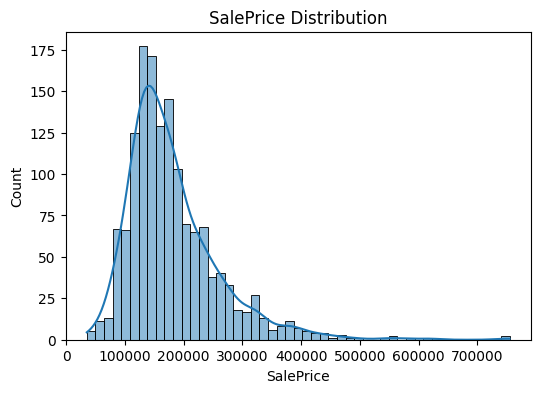

In [2]:
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [3]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

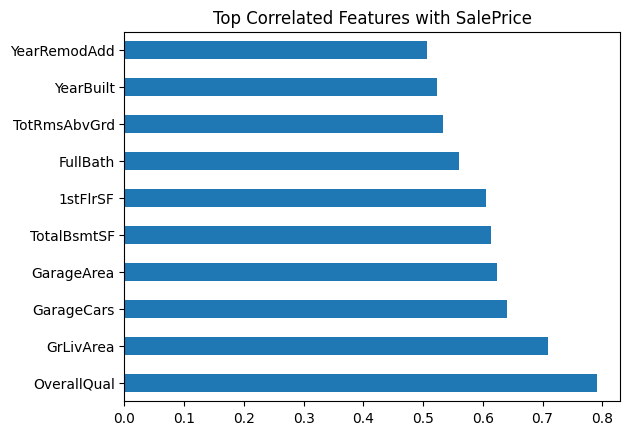

In [4]:
corr = train.corr(numeric_only=True)
top_corr = corr["SalePrice"].sort_values(ascending=False)[1:11]

top_corr.plot(kind="barh")
plt.title("Top Correlated Features with SalePrice")
plt.show()

In [5]:
X = train.drop("SalePrice", axis=1)
y = np.log1p(train["SalePrice"])  # log transform

In [6]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    X[col] = X[col].fillna("Missing")
    test[col] = test[col].fillna("Missing")

In [7]:
X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
test["HouseAge"] = test["YrSold"] - test["YearBuilt"]

X["TotalBathrooms"] = (
    X["FullBath"] + 
    0.5 * X["HalfBath"] +
    X["BsmtFullBath"] +
    0.5 * X["BsmtHalfBath"]
)

test["TotalBathrooms"] = (
    test["FullBath"] + 
    0.5 * test["HalfBath"] +
    test["BsmtFullBath"] +
    0.5 * test["BsmtHalfBath"]
)

In [8]:
drop_cols = ["Id"]
X = X.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [9]:
categorical_features = [
    X.columns.get_loc(col)
    for col in cat_cols
]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from catboost import Pool

train_pool = Pool(X_train, y_train, cat_features=categorical_features)
valid_pool = Pool(X_valid, y_valid, cat_features=categorical_features)

In [12]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

0:	learn: 0.3830721	test: 0.4258358	best: 0.4258358 (0)	total: 275ms	remaining: 22m 54s
200:	learn: 0.0973199	test: 0.1453535	best: 0.1453535 (200)	total: 27.5s	remaining: 10m 56s
400:	learn: 0.0741267	test: 0.1354585	best: 0.1354585 (400)	total: 1m 5s	remaining: 12m 28s
600:	learn: 0.0605587	test: 0.1336352	best: 0.1336352 (600)	total: 1m 44s	remaining: 12m 41s
800:	learn: 0.0492229	test: 0.1332283	best: 0.1330514 (722)	total: 2m 16s	remaining: 11m 57s
1000:	learn: 0.0410126	test: 0.1326674	best: 0.1326200 (988)	total: 2m 48s	remaining: 11m 13s
1200:	learn: 0.0349037	test: 0.1325418	best: 0.1325090 (1159)	total: 3m 20s	remaining: 10m 33s
1400:	learn: 0.0307375	test: 0.1324972	best: 0.1324792 (1390)	total: 3m 49s	remaining: 9m 49s
1600:	learn: 0.0268620	test: 0.1324094	best: 0.1323994 (1588)	total: 4m 19s	remaining: 9m 11s
1800:	learn: 0.0233580	test: 0.1323482	best: 0.1323359 (1776)	total: 4m 52s	remaining: 8m 38s
2000:	learn: 0.0204220	test: 0.1322379	best: 0.1322326 (1984)	total: 5m

In [13]:
from sklearn.metrics import mean_squared_error

preds_log = model.predict(X_valid)
preds = np.expm1(preds_log)
y_valid_real = np.expm1(y_valid)

rmse = np.sqrt(mean_squared_error(y_valid_real, preds))
print("Final RMSE:", rmse)

Final RMSE: 27051.23949789128


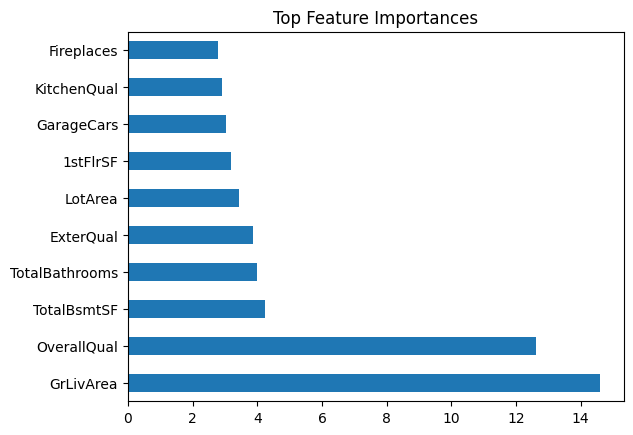

In [14]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top Feature Importances")
plt.show()

In [15]:
full_pool = Pool(X, y, cat_features=categorical_features)
model.fit(full_pool, verbose=200)

0:	learn: 0.3913434	total: 92.8ms	remaining: 7m 43s
200:	learn: 0.0965195	total: 26.2s	remaining: 10m 24s
400:	learn: 0.0780249	total: 56.4s	remaining: 10m 46s
600:	learn: 0.0689642	total: 1m 29s	remaining: 10m 53s
800:	learn: 0.0575263	total: 2m 2s	remaining: 10m 44s
1000:	learn: 0.0486920	total: 2m 34s	remaining: 10m 17s
1200:	learn: 0.0418920	total: 3m 6s	remaining: 9m 49s
1400:	learn: 0.0366988	total: 3m 37s	remaining: 9m 18s
1600:	learn: 0.0323397	total: 4m 6s	remaining: 8m 43s
1800:	learn: 0.0284063	total: 4m 34s	remaining: 8m 8s
2000:	learn: 0.0249769	total: 5m 6s	remaining: 7m 38s
2200:	learn: 0.0220990	total: 5m 38s	remaining: 7m 11s
2400:	learn: 0.0195413	total: 6m 10s	remaining: 6m 41s
2600:	learn: 0.0177442	total: 6m 44s	remaining: 6m 13s
2800:	learn: 0.0158569	total: 7m 16s	remaining: 5m 42s
3000:	learn: 0.0140954	total: 7m 45s	remaining: 5m 10s
3200:	learn: 0.0125773	total: 8m 14s	remaining: 4m 37s
3400:	learn: 0.0112619	total: 8m 44s	remaining: 4m 6s
3600:	learn: 0.01010

In [16]:
final_preds = np.expm1(model.predict(test))

submission = pd.DataFrame({
    "SalePrice": final_preds
})

submission.to_csv("final_predictions.csv", index=False)